# Data retrieval

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Data cleaning

### Irrelevant cols

In [8]:
df.drop('Id', axis=1, inplace=True)

### Duplicates 

In [9]:
df.duplicated().sum()

np.int64(3)

In [24]:
df.drop_duplicates(inplace=True)

### Missing values

In [10]:
df.isna().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

### Outliers

In [14]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


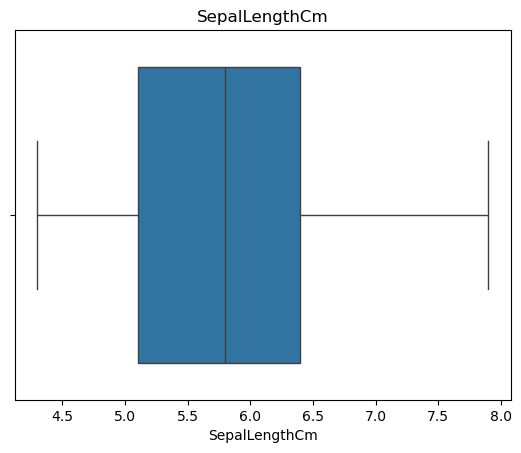

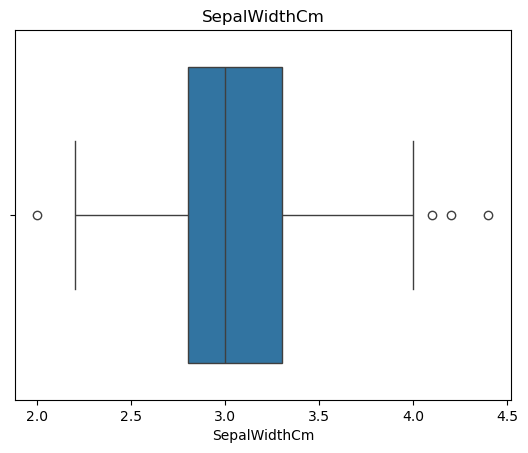

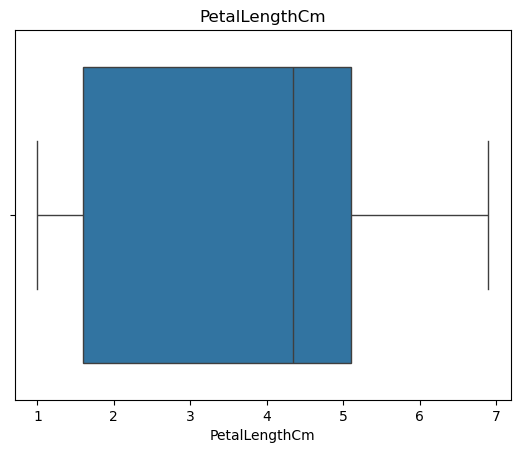

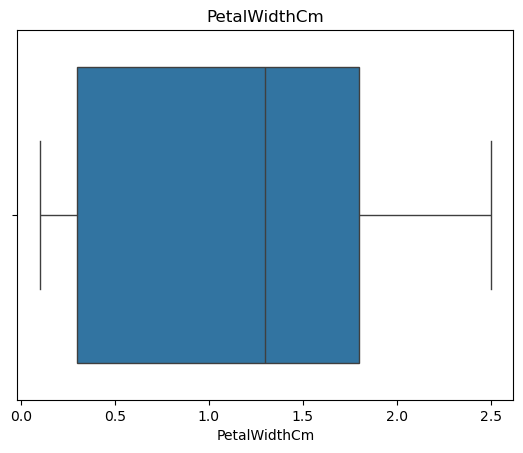

In [16]:
cols = df.columns.drop('Species')

for col in cols:
    sns.boxplot(df[col], orient='h')
    plt.title(f'{col}')
    plt.show()

In [25]:
from scipy.stats.mstats import winsorize

In [26]:
df['SepalWidthCm'] = winsorize(df['SepalWidthCm'], limits=[0.01,0.01])

# Data preprocessing

In [27]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [28]:
ss = StandardScaler()
df[cols] = ss.fit_transform(df[cols])

In [29]:
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Data splitting

In [30]:
from sklearn.model_selection import train_test_split

In [33]:
X = df[cols]
y = df['Species']

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [48]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(117, 4) (117,) (30, 4) (30,)


### Class imbalance

In [49]:
y.value_counts()

Species
1    50
2    49
0    48
Name: count, dtype: int64

In [50]:
y.value_counts(normalize=True)

Species
1    0.340136
2    0.333333
0    0.326531
Name: proportion, dtype: float64

# Model selection

In [51]:
from sklearn.svm import SVC

In [52]:
model = SVC()
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Evaluation

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [54]:
y_pred = model.predict(X_test)

In [55]:
acc = model.score(X_test, y_test)
pre = precision_score(y_test, y_pred, average='macro')
re = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')
cr = classification_report(y_test, y_pred)

In [56]:
print(f"Accuracy Score       : {acc:.4f}")
print(f"Precision Score      : {pre:.4f}")
print(f"Recall Score         : {re:.4f}")
print(f"F1 Score             : {f1:.4f}")
print("\nClassification Report:\n")
print(cr)

Accuracy Score       : 0.9667
Precision Score      : 0.9697
Recall Score         : 0.9667
F1 Score             : 0.9666

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



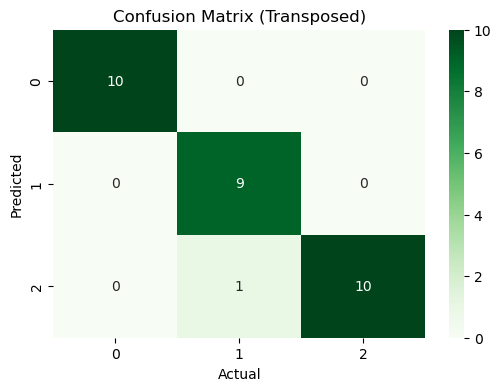

In [57]:
cmx = confusion_matrix(y_test, y_pred)
cmx = cmx.T
plt.figure(figsize=(6,4))
sns.heatmap(cmx, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix (Transposed)")
plt.show()